In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

df = pd.read_csv("Mall_Customers.csv")
le = LabelEncoder() # Initialize LabelEncoder here

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df["Gender"] = le.fit_transform(df["Gender"])

In [ ]:
df["Purchase_Category"] = np.where(
    df["Annual Income (k$)"] >= 70,
    "High",
    "Low"
)

In [ ]:
df["Purchase_Category"] = le.fit_transform(df["Purchase_Category"])

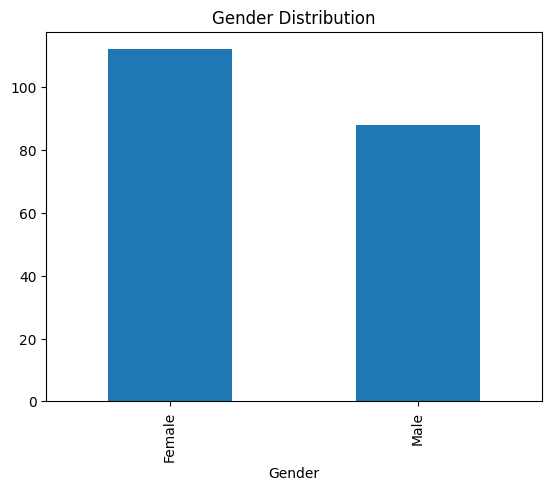

In [ ]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")

plt.show()

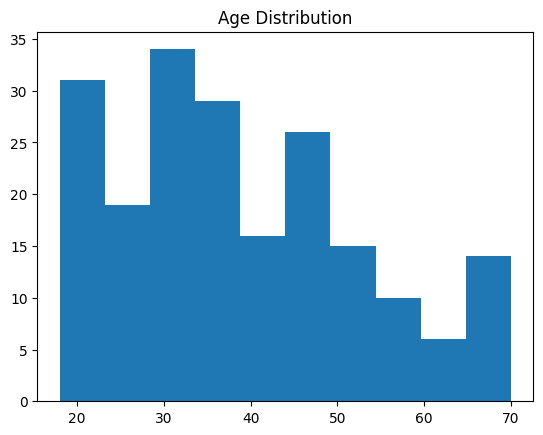

In [ ]:
plt.hist(df["Age"])

plt.title("Age Distribution")

plt.show()

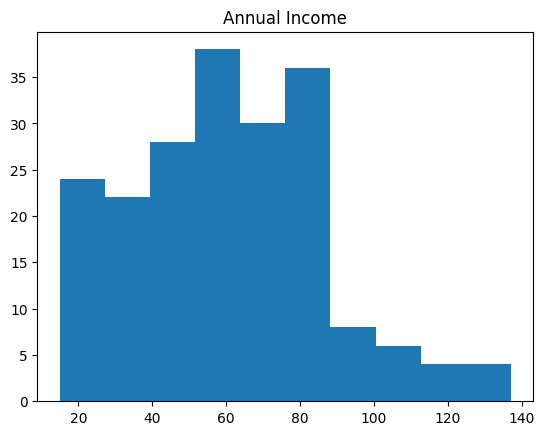

In [ ]:
plt.hist(df["Annual Income (k$)"])

plt.title("Annual Income")

plt.show()

In [ ]:
X = df.drop("Purchase_Category", axis=1)

y = df["Purchase_Category"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

df = pd.read_csv("Mall_Customers.csv")

# Initialize LabelEncoder for encoding categorical features
le_gender = LabelEncoder()

# Apply Label Encoding to the 'Gender' column in X_train and X_test
# Make a copy to avoid SettingWithCopyWarning
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded['Gender'] = le_gender.fit_transform(X_train_encoded['Gender'])
X_test_encoded['Gender'] = le_gender.transform(X_test_encoded['Gender']) # Use transform, not fit_transform for test set

model = RandomForestClassifier(random_state=42)

model.fit(X_train_encoded,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
prediction = model.predict(X_test_encoded)

In [ ]:
accuracy = accuracy_score(y_test,prediction)

print("Accuracy :",accuracy)

Accuracy : 0.95


In [ ]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        17
           1       0.92      1.00      0.96        23

    accuracy                           0.95        40
   macro avg       0.96      0.94      0.95        40
weighted avg       0.95      0.95      0.95        40



In [ ]:
print(confusion_matrix(y_test,prediction))

[[15  2]
 [ 0 23]]


In [ ]:
new_customer = [[
    201,      # CustomerID
    1,        # Gender (Male=1)
    30,       # Age
    80,       # Annual Income
    60        # Spending Score
]]

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("High Purchase Customer")
else:
    print("Low Purchase Customer")

Low Purchase Customer


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
